Analyse stiener graph RWR probs

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, ttest_1samp
%matplotlib inline

In [2]:
rwr_prob = pd.read_csv('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data/NAMPT_DAPO_RWR_PROBS.CSV', header = 0, index_col=0)
rwr_prob.head()

,rwr_prob,gene,NAMPT_KEGG,FORGE_HCG
NDUFV2,0.000010,NDUFV2,no,no
TUBA3D,0.000195,TUBA3D,no,no
TPD52L2,0.000008,TPD52L2,no,no
NLRC5,0.000374,NLRC5,no,no
BMP1,0.000066,BMP1,no,no


In [3]:
x = rwr_prob['rwr_prob'].values

iqr = np.quantile(x, 0.75) - np.quantile(x, 0.25)
iqr = max(iqr, 1e-8)   # numerical floor

z = (x - np.median(x)) / iqr

rwr_prob['log_scaled_rwr'] = np.sign(z) * np.log10(1 + np.abs(z))


In [4]:
df = rwr_prob.copy()

In [5]:
df.head()

,rwr_prob,gene,NAMPT_KEGG,FORGE_HCG,log_scaled_rwr
NDUFV2,0.000010,NDUFV2,no,no,-0.126978
TUBA3D,0.000195,TUBA3D,no,no,0.558682
TPD52L2,0.000008,TPD52L2,no,no,-0.135951
NLRC5,0.000374,NLRC5,no,no,0.812356
BMP1,0.000066,BMP1,no,no,0.191442


In [6]:
deg_res = pd.read_csv('/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Data/Daporinad_NAMPT_depMap_keyCluster_deg_optuna.csv',
    header = 0, index_col = 0)
deg_res.head()

,logFC,AveExpr,t,P.Value,adj.P.Val,B
TJP1,-7.445249,6.014405,-31.726646,5.739472e-134,9.349026e-130,295.128472
SEPTIN10,-7.104150,5.350026,-30.134651,2.489744e-125,2.027772e-121,275.365139
NCKAP1,-5.355830,7.387902,-29.267260,1.367787e-120,7.426626e-117,264.517181
TEAD1,-6.612842,6.519932,-29.172419,4.524184e-120,1.842361e-116,263.328071
NLRC3,5.103630,0.025539,28.809572,4.418661e-118,1.439511e-114,258.773650


In [7]:
deg_res['gene'] = deg_res.index
deg_res.head()

,logFC,AveExpr,t,P.Value,adj.P.Val,B,gene
TJP1,-7.445249,6.014405,-31.726646,5.739472e-134,9.349026e-130,295.128472,TJP1
SEPTIN10,-7.104150,5.350026,-30.134651,2.489744e-125,2.027772e-121,275.365139,SEPTIN10
NCKAP1,-5.355830,7.387902,-29.267260,1.367787e-120,7.426626e-117,264.517181,NCKAP1
TEAD1,-6.612842,6.519932,-29.172419,4.524184e-120,1.842361e-116,263.328071,TEAD1
NLRC3,5.103630,0.025539,28.809572,4.418661e-118,1.439511e-114,258.773650,NLRC3


In [8]:
merged_df = pd.merge(left=df, right = deg_res, left_on='gene', right_on = 'gene', how='inner')
merged_df.head()

,rwr_prob,gene,NAMPT_KEGG,FORGE_HCG,log_scaled_rwr,logFC,AveExpr,t,P.Value,adj.P.Val,B
0,0.000010,NDUFV2,no,no,-0.126978,0.175361,6.292569,1.801688,7.205972e-02,9.940556e-02,-5.927303
1,0.000195,TUBA3D,no,no,0.558682,0.617014,-1.841840,3.142493,1.751662e-03,3.263132e-03,-2.649986
2,0.000008,TPD52L2,no,no,-0.135951,-0.715128,7.396209,-8.059113,3.714715e-15,3.144958e-14,23.360771
3,0.000374,NLRC5,no,no,0.812356,2.188779,3.581202,7.243571,1.246286e-12,8.159466e-12,17.647929
4,0.000066,BMP1,no,no,0.191442,-1.176504,4.950862,-5.649558,2.411357e-08,9.126069e-08,8.013585


In [9]:
merged_df.shape

(1452, 11)

In [10]:
merged_df['deg_type'] = np.where(merged_df['adj.P.Val'] < 0.05, 
    np.where(merged_df['logFC'] > 1, 'upregulated', 'downregulated'), 'non_significant')

In [11]:
merged_df['deg_type'].value_counts()

deg_type
downregulated      948
non_significant    369
upregulated        135
Name: count, dtype: int64

In [12]:
# --- mutually exclusive membership ---
def assign_membership(row):
    
    # Priority 1: FORGE_HCG
    if row['FORGE_HCG'] == 'yes':
        return 'FORGE_HCG'
    
    # Priority 2: KEGG
    elif row['NAMPT_KEGG'] == 'yes':
        return 'KEGG'
    
    # Priority 3: DEG (only if not in above)
    elif row['deg_type'] == 'upregulated':
        return 'DEG_up'
    elif row['deg_type'] == 'downregulated':
        return 'DEG_down'
    elif row['deg_type'] == 'non_significant':
        return 'non_significant'
    
    # fallback
    else:
        return 'no_member'

In [13]:
merged_df['membership'] = merged_df.apply(assign_membership, axis=1)

# --- final long df ---
long_df = merged_df[['gene', 'membership', 'log_scaled_rwr']].dropna()

# check counts
print(long_df['membership'].value_counts())

membership
DEG_down           799
non_significant    358
FORGE_HCG          146
DEG_up             121
KEGG                28
Name: count, dtype: int64


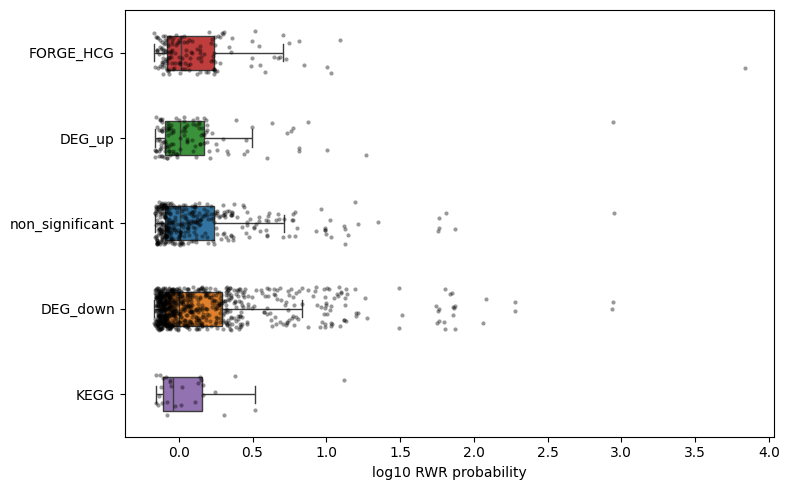

In [14]:
# --- compute order based on median ---
order = (
    long_df.groupby('membership')['log_scaled_rwr']
    .median()
    .sort_values(ascending=False)   # highest median on top
    .index
)

plt.figure(figsize=(8, 5))

# --- horizontal boxplot ---
sns.boxplot(
    data=long_df,
    y='membership',
    x='log_scaled_rwr',
    order=order,
    width=0.4,
    hue='membership', showfliers=False   # hides outlier dots
)

# --- stripplot ---
sns.stripplot(
    data=long_df,
    y='membership',
    x='log_scaled_rwr',
    order=order,
    color='black',
    jitter=0.25,
    alpha=0.4,
    size=3
)

plt.ylabel('')
plt.xlabel('log10 RWR probability')
plt.tight_layout()

# Optional: clean legend (since hue duplicates)
plt.savefig('nampt_rwr_probs_sorted.pdf', dpi=300, bbox_inches='tight')

plt.show()

In [15]:
merged_df.to_csv('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/revision_final/NAMPT_RWR_Probs_full.csv',
 index=True)